# Credit Default Prediction Model – Portfolio Risk Analysis

## Objective
This project builds a machine learning model to estimate Probability of Default (PD) for a simulated loan portfolio.

## Business Use Case
- Support credit approval decisions
- Estimate Expected Loss (PD × LGD × EAD)
- Enable risk-based segmentation of borrowers

## Dataset
Synthetic dataset of ~12,000 loans simulating real-world credit characteristics.

## Data Generation

Due to lack of access to real bank data, a synthetic dataset was generated to simulate:
- Credit scores
- Income levels
- Loan characteristics
- Default behavior

The relationships were designed to reflect real-world credit risk dynamics.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
import shap


In [2]:
# 1. SETUP: Deterministic Seed for Audits
np.random.seed(42)
num_users = 10000

# 2. DIM_USERS: Profile Data
users = pd.DataFrame({
    'user_id': range(1, num_users + 1),
    'age': np.random.randint(18, 70, size=num_users),
    'annual_income': np.random.normal(65000, 25000, size=num_users).clip(20000, 250000),
    'credit_score': np.random.randint(300, 850, size=num_users),
    'employment_status': np.random.choice(['Employed', 'Self-Employed', 'Contractor'], num_users, p=[0.7, 0.2, 0.1])
})

# 3. FACT_LOANS: Origination Data
num_loans = 12000
loans = pd.DataFrame({
    'loan_id': range(101, 101 + num_loans),
    'user_id': np.random.choice(users['user_id'], size=num_loans),
    'loan_amount': np.random.choice([5000, 10000, 15000, 25000], size=num_loans),
    'origination_date': [datetime(2024, 1, 1) + timedelta(days=np.random.randint(0, 365)) for _ in range(num_loans)],
    'term_months': np.random.choice([12, 24, 36], size=num_loans)
})

# 4. FACT_REPAYMENTS: Performance Data with LOGICAL RISK
# We merge to calculate risk BEFORE generating repayment status
perf = loans.merge(users, on='user_id')

# Risk Logic: Probability of default increases if Credit Score or Income is low
perf['pd_prob'] = (
    ((1 - (perf['credit_score'] - 300) / 550) ** 2) * 0.7 +
    ((1 - (perf['annual_income'] / 250000)) ** 2) * 0.3
).clip(0, 1) * 0.6

repayments = []
pd_adj = np.clip(perf['pd_prob'] * 1.5, 0, 1)

for idx, row in perf.iterrows():
    is_defaulter = np.random.random() < pd_adj.loc[idx]
    default_month = np.random.randint(3, 12) if is_defaulter else 999
    
    for m in range(1, 13):
        status = 'Default' if m >= default_month else 'Current'
        repayments.append({'loan_id': row['loan_id'], 'month_on_books': m, 'status': status})

fact_repayments = pd.DataFrame(repayments)

# 5. EXPORT: Save for SQL Loading
users.to_csv('dim_users.csv', index=False)
loans.to_csv('fact_loans.csv', index=False)
fact_repayments.to_csv('fact_repayments.csv', index=False)

print("✅ v2.0 Data Factory: Files generated with Logical Risk patterns.")

✅ v2.0 Data Factory: Files generated with Logical Risk patterns.


## Exploratory Data Analysis (EDA)

### Objective
This section examines the synthetic loan portfolio to understand the relationship between borrower characteristics and default behavior.

### Key questions
- What does the portfolio look like?
- Which borrower attributes appear most associated with default?
- Are there clear risk gradients across credit score, income, and loan size?

### Interpretation standard
The purpose of this analysis is not to build the model yet, but to validate whether the data contains economically sensible risk patterns before modeling.

## Data Understanding

The dataset consists of three core tables:

- `dim_users`: borrower demographic and financial profile
- `fact_loans`: loan origination details
- `fact_repayments`: monthly loan performance (status over time)

At this stage, no target variable (default flag) exists yet.  
We first explore the raw structure before deriving analytical features.

In [3]:
users.head()
loans.head()
fact_repayments.head()

,loan_id,month_on_books,status
0,101,1,Current
1,101,2,Current
2,101,3,Current
3,101,4,Current
4,101,5,Current


## Exploratory Data Analysis (Raw Data)

We begin by analyzing borrower and loan characteristics before defining default.

This helps verify:
- Data realism
- Distribution of key variables
- Portfolio composition

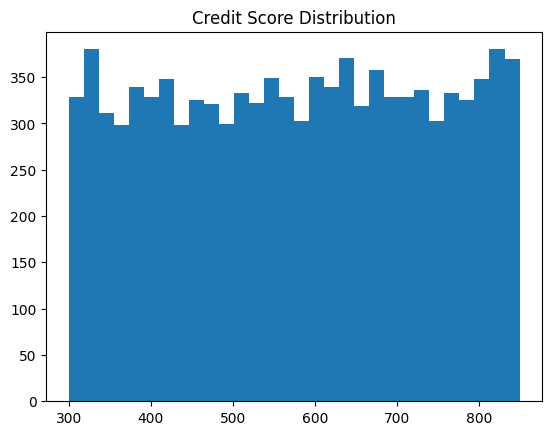

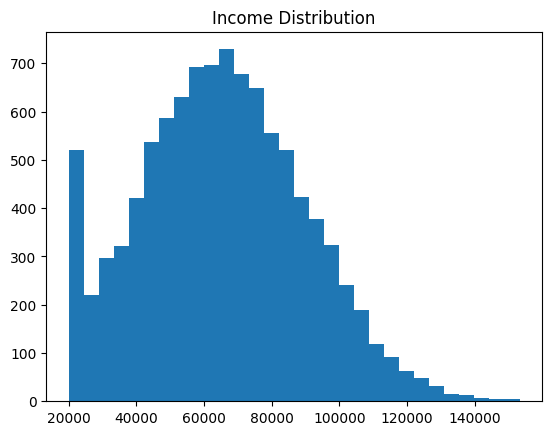

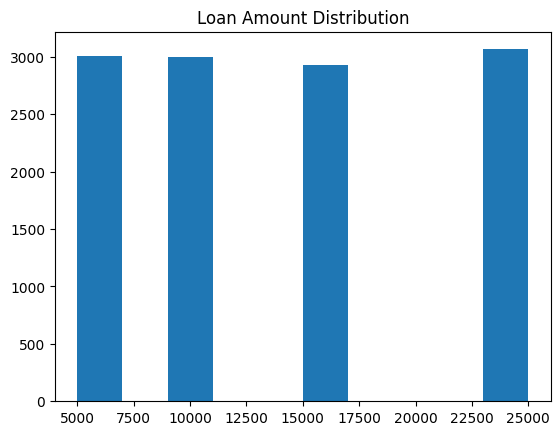

In [4]:
# Credit score
plt.hist(users['credit_score'], bins=30)
plt.title("Credit Score Distribution")
plt.show()

# Income
plt.hist(users['annual_income'], bins=30)
plt.title("Income Distribution")
plt.show()

# Loan amount
plt.hist(loans['loan_amount'], bins=10)
plt.title("Loan Amount Distribution")
plt.show()

The distributions appear realistic, with a broad spread across credit scores, income, and loan sizes.

## Loan Performance Analysis

The repayment table tracks each loan’s status over time.

Key objective:
- Understand how defaults evolve across the loan lifecycle

In [5]:
fact_repayments['status'].value_counts()

status
Current    118277
Default     25723
Name: count, dtype: int64

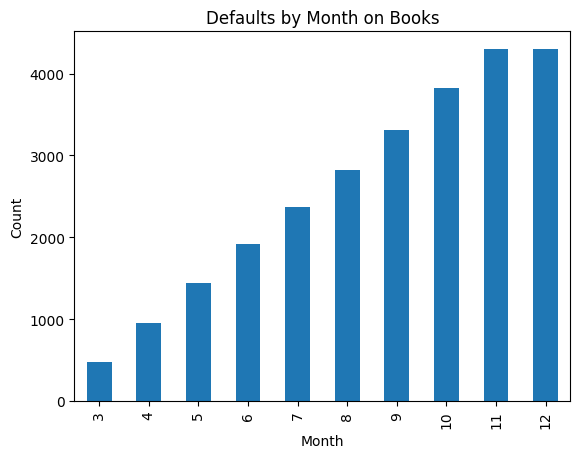

In [6]:
defaults = fact_repayments[fact_repayments['status'] == 'Default']

default_timing = defaults.groupby('month_on_books').size()

default_timing.plot(kind='bar')
plt.title("Defaults by Month on Books")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

Defaults tend to occur after a few months on books, which aligns with real-world credit behavior.

## Target Definition (Default Flag)

A loan is classified as defaulted if it enters 'Default' status at any point in its lifecycle.

This converts transactional repayment data into a borrower-level outcome variable.

In [7]:
default_flag = (
    fact_repayments
    .groupby('loan_id')['status']
    .apply(lambda x: 1 if 'Default' in x.values else 0)
    .reset_index(name='is_default')
)

default_flag.head()

,loan_id,is_default
0,101,0
1,102,0
2,103,1
3,104,0
4,105,1


## Master Analytical File (MAF)

We combine:
- Loan data
- Borrower data
- Default outcome

This creates the dataset used for modeling.

In [8]:
maf = loans.merge(users, on='user_id').merge(default_flag, on='loan_id')

maf.head()

,loan_id,user_id,loan_amount,origination_date,term_months,age,annual_income,credit_score,employment_status,is_default
0,101,906,5000,2024-03-13,36,34,113556.139869,300,Contractor,0
1,102,8142,5000,2024-10-25,24,67,123601.344471,649,Employed,0
2,103,1883,25000,2024-04-14,12,62,20000.000000,667,Employed,1
3,104,492,10000,2024-10-18,12,18,63303.215458,690,Employed,0
4,105,7812,15000,2024-08-19,12,32,65771.237319,434,Employed,1


In [9]:
maf.to_csv("master_analytical_file.csv", index=False)

## Exploratory Data Analysis (With Default Outcome)

Now that the default flag is defined, we analyze how borrower attributes relate to credit risk.

In [10]:
maf['is_default'].mean()

np.float64(0.35841666666666666)

In [11]:
maf.groupby(pd.qcut(maf['credit_score'], 5))['is_default'].mean()

credit_score
(299.999, 406.8]    0.652500
(406.8, 524.0]      0.460232
(524.0, 630.0]      0.315195
(630.0, 742.0]      0.221390
(742.0, 849.0]      0.141604
Name: is_default, dtype: float64

In [12]:
maf.groupby(pd.qcut(maf['annual_income'], 5))['is_default'].mean()

annual_income
(19999.999, 43973.789]     0.437136
(43973.789, 58243.282]     0.392410
(58243.282, 71181.786]     0.357351
(71181.786, 85781.716]     0.323051
(85781.716, 150722.762]    0.282083
Name: is_default, dtype: float64

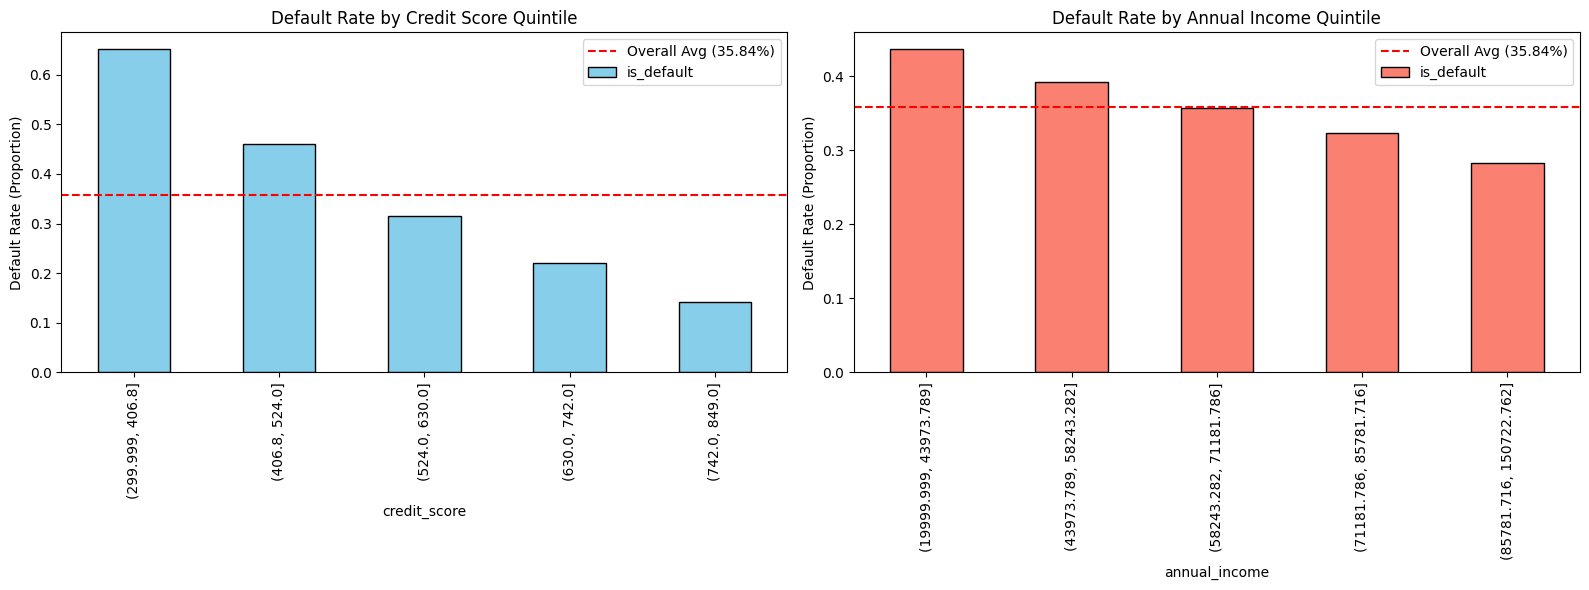

In [13]:
# Calculate the baseline average for the reference line
baseline = maf['is_default'].mean()

# Set up a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Default Rate by Credit Score
# We use the same logic you used for grouping
credit_groups = maf.groupby(pd.qcut(maf['credit_score'], 5))['is_default'].mean()
credit_groups.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].axhline(baseline, color='red', linestyle='--', label=f'Overall Avg ({baseline:.2%})')
axes[0].set_title('Default Rate by Credit Score Quintile')
axes[0].set_ylabel('Default Rate (Proportion)')
axes[0].legend()

# 2. Plot Default Rate by Annual Income
income_groups = maf.groupby(pd.qcut(maf['annual_income'], 5))['is_default'].mean()
income_groups.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].axhline(baseline, color='red', linestyle='--', label=f'Overall Avg ({baseline:.2%})')
axes[1].set_title('Default Rate by Annual Income Quintile')
axes[1].set_ylabel('Default Rate (Proportion)')
axes[1].legend()

plt.tight_layout()
plt.savefig('EDA-plot-1.png', bbox_inches='tight')
plt.show()

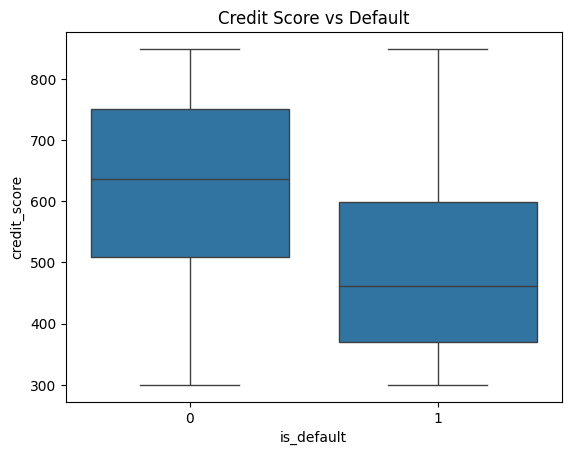

In [14]:
sns.boxplot(x='is_default', y='credit_score', data=maf)
plt.title("Credit Score vs Default")
plt.savefig('EDA-plot-2.png', bbox_inches='tight')
plt.show()

Lower credit scores are strongly associated with higher default rates.

Income also shows a predictive effect, though weaker than credit score.

These relationships confirm that the dataset contains meaningful risk signals.

## Feature Engineering

This step transforms raw borrower and loan data into features suitable for predictive modeling.

The goal is to capture key dimensions of credit risk:

- **Creditworthiness** → credit score
- **Repayment capacity** → income
- **Exposure size** → loan amount

Feature engineering is guided by insights from the EDA and domain knowledge in credit risk.

Care is taken to avoid data leakage by ensuring that only information available at loan origination is used.

In [15]:
features = ['credit_score', 'annual_income', 'loan_amount', 'age']
df_model = maf[features + ['is_default']].copy()

df_model.head()

,credit_score,annual_income,loan_amount,age,is_default
0,300,113556.139869,5000,34,0
1,649,123601.344471,5000,67,0
2,667,20000.000000,25000,62,1
3,690,63303.215458,10000,18,0
4,434,65771.237319,15000,32,1


### Derived Features

Additional features are created to better represent borrower risk:

- Income-to-loan ratio (affordability proxy)
- Normalized credit score

In [16]:
# Income-to-loan ratio (affordability)
df_model['income_to_loan'] = df_model['annual_income'] / df_model['loan_amount']

# Normalize credit score (0–1 scale)
df_model['credit_score_norm'] = (df_model['credit_score'] - 300) / (850 - 300)

df_model.head()

,credit_score,annual_income,loan_amount,age,is_default,income_to_loan,credit_score_norm
0,300,113556.139869,5000,34,0,22.711228,0.000000
1,649,123601.344471,5000,67,0,24.720269,0.634545
2,667,20000.000000,25000,62,1,0.800000,0.667273
3,690,63303.215458,10000,18,0,6.330322,0.709091
4,434,65771.237319,15000,32,1,4.384749,0.243636


To better capture a borrower's creditworthiness, we are transforming raw data into features that reflect industry-standard risk assessment.

### 1. Income-to-Loan Ratio (Affordability)
Rather than looking at income or loan amounts in isolation, we calculate the Income-to-Loan Ratio. 

*   **Logic:** A high income doesn't mitigate risk if the loan amount is disproportionately large. Conversely, a large loan is less risky if the borrower has the "capacity" to repay it through high earnings.
*   **The Formula:**
$$\text{income\_to\_loan} = \frac{\text{annual\_income}}{\text{loan\_amount}}$$

---

### 2. Credit Score Normalization (Feature Scaling)
Since raw credit scores typically range from 300 to 850, we normalize them to a 0–1 scale using Min-Max scaling.

*   **Why this matters:** Machine learning models often perform better when features are on the same scale. This prevents the model from giving undue weight to the credit score simply because its raw numerical value is higher than the income ratio.
*   **The Transformation:**
$$\text{norm\_score} = \frac{\text{score} - 300}{850 - 300}$$

### Feature Binning

Continuous variables are grouped into bands to capture non-linear risk patterns and improve interpretability.

In [17]:
df_model['credit_score_band'] = pd.cut(
    df_model['credit_score'],
    bins=[300, 500, 600, 700, 850],
    labels=[1, 2, 3, 4]
)

df_model['income_band'] = pd.qcut(df_model['annual_income'], q=5, labels=False)

In [18]:
final_features = [
    'credit_score',
    'annual_income',
    'loan_amount',
    'age',
    'income_to_loan',
    'credit_score_norm',
    'credit_score_band'
]

X = df_model[final_features]
y = df_model['is_default']

### Final Feature Set

The final model uses both raw and engineered features to capture multiple dimensions of credit risk.

Engineered features such as income-to-loan ratio improve the model’s ability to assess affordability and exposure.

This feature set is designed to balance predictive performance with interpretability.

## Model Development

A machine learning model is developed to estimate the Probability of Default (PD) for each loan.

### Model Choice: Random Forest

Random Forest is selected due to:
- Ability to capture nonlinear relationships
- Robustness to noisy data
- Strong performance on structured/tabular datasets

### Modeling Approach
- Binary classification problem (Default vs Non-Default)
- Supervised learning using historical loan outcomes
- Evaluation based on probability predictions (PD)

The dataset is split into training and testing sets to evaluate out-of-sample performance.

In [19]:
# Train-test split (stratified to preserve default rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (9600, 7)
Test size: (2400, 7)


### Model Training

The Random Forest model is trained using balanced class weights to account for class imbalance in default data.

In [20]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Model Predictions

The model outputs predicted probabilities, which represent the estimated Probability of Default (PD).

In [21]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

## Model Performance Evaluation

The model is evaluated using:

- AUC (Area Under the ROC Curve) — measures ranking ability
- Classification metrics — precision, recall, F1-score

AUC is the primary metric in credit risk, as it reflects how well the model distinguishes between good and bad borrowers.

In [22]:
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"AUC Score: {round(auc_score, 4)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

AUC Score: 0.7108

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74      1540
           1       0.54      0.59      0.57       860

    accuracy                           0.67      2400
   macro avg       0.65      0.66      0.65      2400
weighted avg       0.68      0.67      0.68      2400



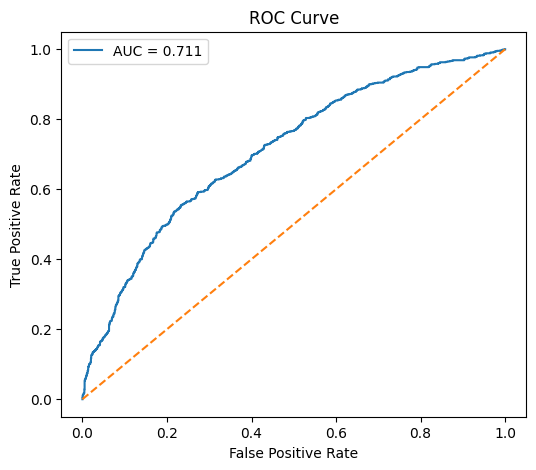

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {round(auc_score, 3)}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig('ROC-Curve.png', bbox_inches='tight')
plt.show()

In [24]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

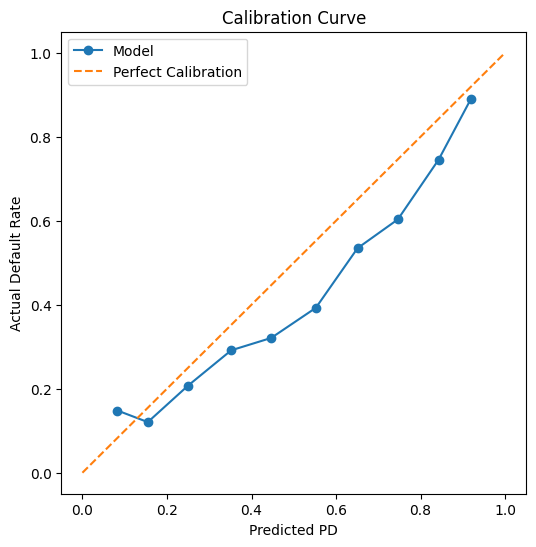

In [25]:
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')
plt.xlabel("Predicted PD")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve")
plt.legend()
plt.savefig('Calibration-Curve.png', bbox_inches='tight')
plt.show()

### Interpretation

- Points close to the diagonal indicate good calibration
- Deviations suggest overestimation or underestimation of risk

Calibration is important for translating model outputs into business decisions.

### Model Calibration Adjustment

Initial analysis showed that predicted probabilities were consistently higher than observed default rates, indicating overestimation of risk.

The model was calibrated using isotonic regression to align predicted probabilities with actual outcomes.

This ensures that PD estimates are suitable for real-world decision-making.

In [26]:
calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=3)
calibrated_model.fit(X_train, y_train)
y_pred_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]

#Rebuilding the dataset
df_eval = X_test.copy()
df_eval['actual'] = y_test.values
df_eval['pd'] = y_pred_proba_cal

df_eval['decile'] = pd.qcut(df_eval['pd'], 10, labels=False)
df_eval['risk_band'] = pd.qcut(df_eval['pd'], 5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

## Decile Analysis

Decile analysis evaluates how well the model ranks borrowers by risk.

Theloans are sorted by predicted Probability of Default (PD) and divided into 10 groups (deciles), from lowest to highest risk.

This helps answer:
- Does the model correctly rank high-risk borrowers?
- How concentrated are defaults in the highest-risk segments?

A strong model will show increasing default rates from low to high deciles.

In [27]:
# Create a dataframe with predictions
df_eval = X_test.copy()
df_eval['actual'] = y_test.values
df_eval['pd'] = y_pred_proba_cal   

# Create deciles (10 buckets)
df_eval['decile'] = pd.qcut(df_eval['pd'], 10, labels=False)

In [28]:
decile_table = df_eval.groupby('decile').agg(
    avg_pd=('pd', 'mean'),
    actual_default_rate=('actual', 'mean'),
    count=('actual', 'count')
).sort_index(ascending=False)

decile_table

,avg_pd,actual_default_rate,count
decile,,,
9,0.686701,0.642857,238
8,0.603012,0.634454,238
7,0.514678,0.526749,243
6,0.412440,0.339130,230
5,0.342098,0.318725,251
4,0.296573,0.329167,240
3,0.259581,0.287500,240
2,0.221565,0.220833,240
1,0.162626,0.168831,231


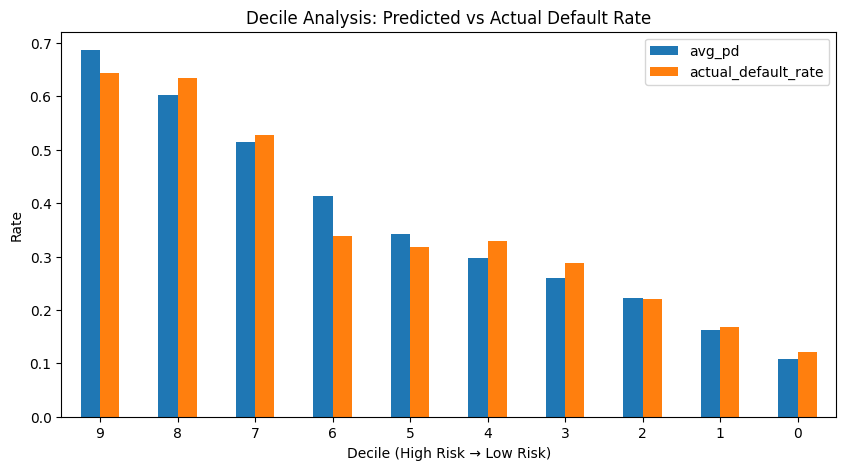

In [29]:
decile_table[['avg_pd', 'actual_default_rate']].plot(kind='bar', figsize=(10,5))
plt.title("Decile Analysis: Predicted vs Actual Default Rate")
plt.xlabel("Decile (High Risk → Low Risk)")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.savefig('decile_analysis.png', bbox_inches='tight')
plt.show()

### Interpretation

The model demonstrates strong rank ordering as default rates increase consistently from low to high deciles.
The highest decile captures a disproportionate share of defaults

This indicates effective discrimination between high-risk and low-risk borrowers.

## Model Explainability (SHAP)

To improve transparency, SHAP (SHapley Additive exPlanations) is used to explain model predictions.

SHAP values quantify the contribution of each feature to a prediction.

This helps answer:
- Which features drive default risk?
- How individual predictions are formed

Explainability is critical in credit risk for regulatory compliance and trust.

In [30]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

C:\Users\HP\AppData\Local\Temp\ipykernel_11076\449453499.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


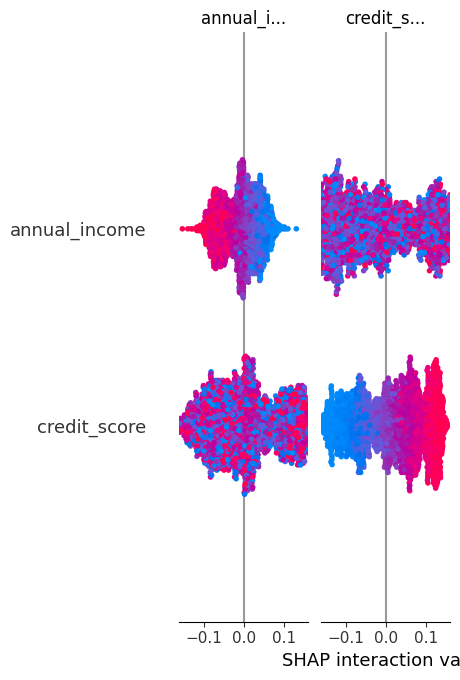

In [31]:
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

### Explainability Insights

Credit score is the dominant driver of default risk, with lower scores significantly increasing risk.

Income contributes as a secondary factor, reflecting repayment capacity.

The model captures realistic relationships between borrower characteristics and default risk.

## Credit Decision Strategy

The model outputs predicted probabilities of default (PD), which can be used to guide credit decisions.

Borrowers can be segmented into risk bands based on PD, enabling:
- Approval decisions
- Risk-based pricing
- Portfolio monitoring

This bridges the gap between model outputs and real-world credit policy.

In [32]:
# Create risk bands
df_eval['risk_band'] = pd.qcut(
    df_eval['pd'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

df_eval[['pd', 'risk_band']].head()

,pd,risk_band
2115,0.324367,Medium
9969,0.546494,High
7175,0.479173,High
9004,0.602432,Very High
10396,0.402000,High


In [33]:
risk_summary = df_eval.groupby('risk_band').agg(
    avg_pd=('pd', 'mean'),
    actual_default_rate=('actual', 'mean'),
    count=('actual', 'count')
)

risk_summary

,avg_pd,actual_default_rate,count
risk_band,,,
Very Low,0.134235,0.143750,480
Low,0.240573,0.254167,480
Medium,0.319846,0.323829,491
High,0.464964,0.435518,473
Very High,0.644856,0.638655,476


### Risk Band Interpretation

- Very Low / Low Risk: Low default rates → suitable for approval
- Medium Risk: Moderate default rates → may require additional checks
- High / Very High Risk: Elevated default rates → candidates for rejection or pricing adjustments

This segmentation allows the bank to align risk appetite with lending decisions.

In [47]:
loan_default = (
    fact_repayments
    .groupby('loan_id')['status']
    .apply(lambda x: 1 if 'Default' in x.values else 0)
    .reset_index(name='default_flag')
)

In [48]:
df = X_test.copy()
df['predicted_pd'] = model.predict_proba(X_test)[:, 1]
df['default_flag'] = y_test.values
df['loan_amount'] = loans.loc[X_test.index, 'loan_amount']

In [49]:
def segment(pd):
    if pd < 0.2:
        return 'Approve'
    elif pd < 0.4:
        return 'Review'
    else:
        return 'Reject'

df['decision'] = df['predicted_pd'].apply(segment)

In [50]:
df_eval['decision'].value_counts()

decision
Review     1037
Reject      865
Approve     498
Name: count, dtype: int64

In [51]:
decision_summary = df_eval.groupby('decision').agg(
    avg_pd=('pd', 'mean'),
    actual_default_rate=('actual', 'mean'),
    count=('actual', 'count')
)

decision_summary

,avg_pd,actual_default_rate,count
decision,,,
Approve,0.136533,0.146586,498
Reject,0.571984,0.563006,865
Review,0.290330,0.289296,1037


### Strategy Decision Explanation

Approved loans exhibit low observed default rates, indicating effective risk filtering.

Rejected loans capture higher-risk borrowers, reducing portfolio exposure.

## Portfolio Risk Analysis

Expected Loss (EL) is used to quantify the financial risk of lending.

EL = PD × LGD × EAD

Where:
- PD = Probability of Default (model output)
- LGD = Loss Given Default (assumed 40%)
- EAD = Exposure at Default (loan amount)

This provides a monetary view of risk beyond probability alone.

In [52]:
LGD = 0.4
df['expected_loss'] = df['predicted_pd'] * df['loan_amount'] * LGD

In [55]:
df['expected_loss'].describe()

count    2400.000000
mean     2464.925239
std      1886.158132
min       109.070481
25%      1099.417897
50%      1830.992578
75%      3327.245742
max      9323.955172
Name: expected_loss, dtype: float64

In [56]:
df.groupby('decision')['expected_loss'].agg(['mean', 'sum', 'count'])

,mean,sum,count
decision,,,
Approve,818.564902,2.955019e+05,361
Reject,3322.001606,4.378398e+06,1318
Review,1722.497262,1.241921e+06,721


In [57]:
summary = df.groupby('decision').agg(
    predicted_pd=('predicted_pd', 'mean'),
    default_flag=('default_flag', 'mean'),
    expected_loss=('expected_loss', 'mean'),
    volume=('predicted_pd', 'size')   # counts rows safely
).reset_index()

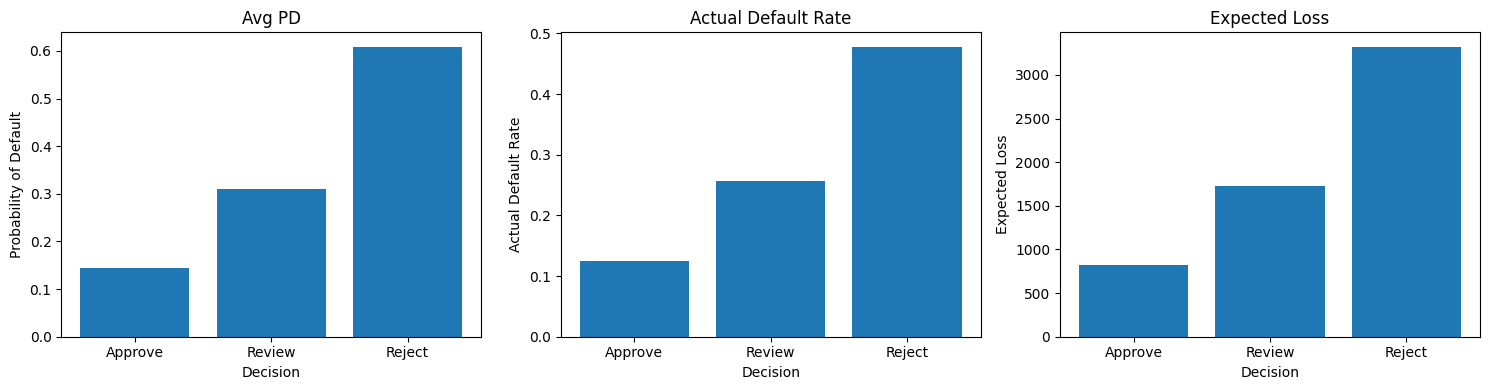

In [58]:
# Sort order
summary = summary.set_index('decision').loc[['Approve', 'Review', 'Reject']].reset_index()

# Create 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Chart 1: Predicted PD ---
axes[0].bar(summary['decision'], summary['predicted_pd'])
axes[0].set_title("Avg PD")
axes[0].set_xlabel("Decision")
axes[0].set_ylabel("Probability of Default")

# --- Chart 2: Default Rate ---
axes[1].bar(summary['decision'], summary['default_flag'])
axes[1].set_title("Actual Default Rate")
axes[1].set_xlabel("Decision")
axes[1].set_ylabel("Actual Default Rate")

# --- Chart 3: Expected Loss ---
axes[2].bar(summary['decision'], summary['expected_loss'])
axes[2].set_title("Expected Loss")
axes[2].set_xlabel("Decision")
axes[2].set_ylabel("Expected Loss")

plt.tight_layout()
plt.show()

### Portfolio Risk Interpretation

The Expected Loss distribution highlights how risk is allocated across lending decisions.

Approved loans exhibit the lowest average risk and contribute minimally to total portfolio risk, indicating effective identification of low-risk borrowers.

Rejected loans show the highest risk levels, confirming that the model successfully isolates high-risk applicants and prevents their inclusion in the portfolio.

The Review segment represents the largest portion of the portfolio and carries a moderate level of risk.

Overall, risk is not evenly distributed but concentrated in specific decision groups, demonstrating that the model effectively segments borrowers and supports targeted risk management strategies.

## Vintage Analysis

Vintage analysis evaluates how loan performance evolves over time by grouping loans into origination cohorts and tracking default behavior across months on books.

In [59]:
# CREATE COHORT
maf['origination_month'] = pd.to_datetime(maf['origination_date']).dt.to_period('M')

In [60]:
# MERGE WITH REPAYMENTS
vintage_df = fact_repayments.merge(
    loans[['loan_id', 'origination_date']],
    on='loan_id'
)

vintage_df['origination_month'] = pd.to_datetime(vintage_df['origination_date']).dt.to_period('M')

In [61]:
# DEFAULT FLAG
vintage_df['default_flag'] = (vintage_df['status'] == 'Default').astype(int)

In [62]:
# AGGREGATE
vintage_table = vintage_df.groupby(
    ['origination_month', 'month_on_books']
).agg(
    default_rate=('default_flag', 'mean')
).reset_index()

In [63]:
# PIVOT
vintage_pivot = vintage_table.pivot(
    index='month_on_books',
    columns='origination_month',
    values='default_rate'
)

In [64]:
vintage_cum = vintage_pivot.cumsum()

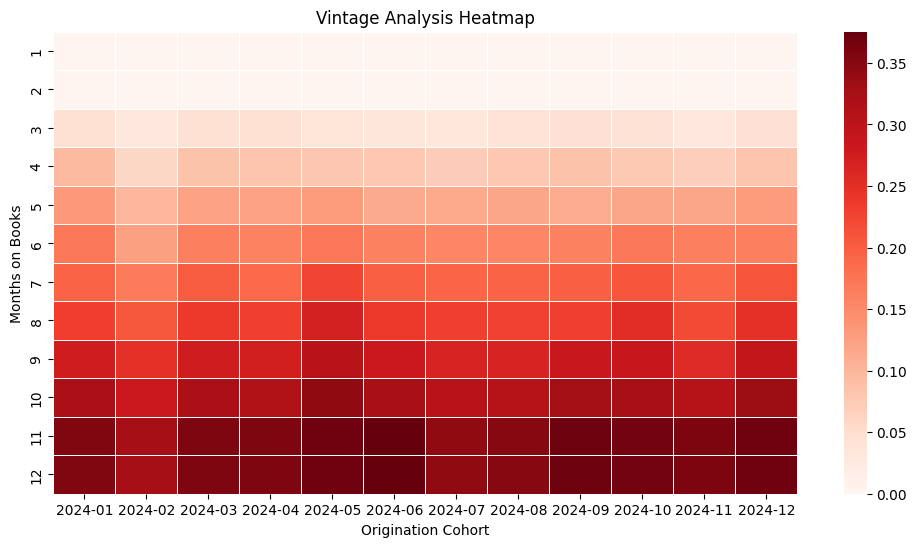

In [65]:
plt.figure(figsize=(12,6))
sns.heatmap(vintage_pivot, cmap="Reds", linewidths=0.5)

plt.title("Vintage Analysis Heatmap")
plt.xlabel("Origination Cohort")
plt.ylabel("Months on Books")
plt.savefig('vintage-analysis.png', bbox_inches='tight')
plt.show()

In [66]:
# Final cumulative default per cohort
final_default = vintage_cum.loc[12]  # month 12

# Sort worst to best
worst_cohorts = final_default.sort_values(ascending=False)

worst_cohorts

origination_month
2024-05    2.305366
2024-12    2.239614
2024-10    2.213613
2024-09    2.181726
2024-01    2.179317
2024-06    2.178468
2024-03    2.171429
2024-04    2.131446
2024-08    2.096210
2024-11    2.073197
2024-07    2.058000
2024-02    1.870934
Freq: M, Name: 12, dtype: float64

In [67]:
threshold = final_default.mean()

bad_cohorts = final_default[final_default > threshold]
bad_cohorts

origination_month
2024-01    2.179317
2024-03    2.171429
2024-05    2.305366
2024-06    2.178468
2024-09    2.181726
2024-10    2.213613
2024-12    2.239614
Freq: M, Name: 12, dtype: float64

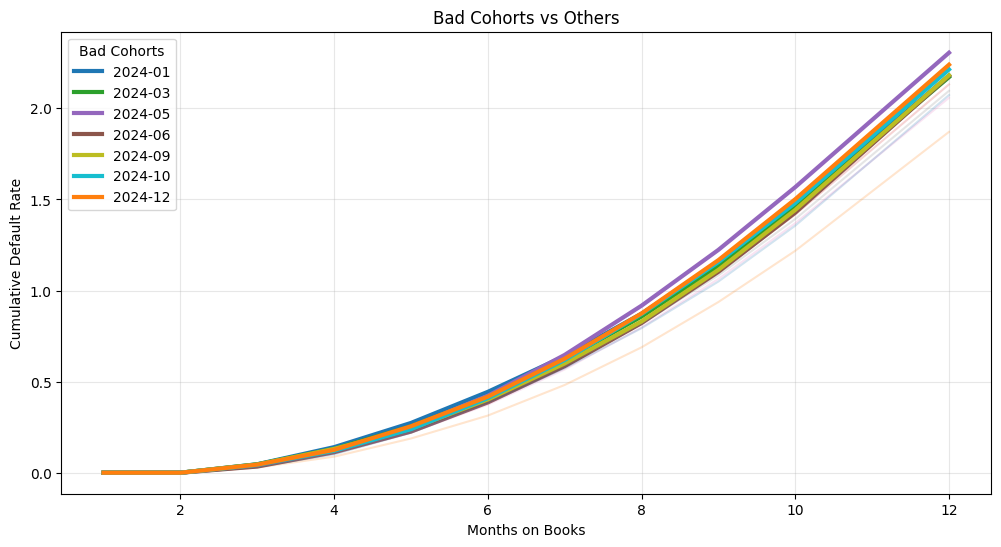

In [68]:
plt.figure(figsize=(12,6))

for col in vintage_cum.columns:
    if col in bad_cohorts.index:
        plt.plot(vintage_cum.index, vintage_cum[col], linewidth=3, label=str(col))
    else:
        plt.plot(vintage_cum.index, vintage_cum[col], alpha=0.2)

plt.title("Bad Cohorts vs Others")
plt.xlabel("Months on Books")
plt.ylabel("Cumulative Default Rate")
plt.legend(title="Bad Cohorts")
plt.grid(alpha=0.3)
plt.show()

## Cohort Risk Driver Investigation

Vintage analysis identified certain origination cohorts with elevated default rates.

To understand the underlying drivers of this performance, we investigate key borrower and loan characteristics at origination.

The objective is to assess whether differences in borrower quality, affordability, or lending strategy are associated with higher observed default rates across cohorts.

The following dimensions are analyzed:

- Credit quality (credit score)
- Borrower affordability (income)
- Loan exposure (loan amount)

### Credit Quality Analysis

Credit score is a primary indicator of borrower risk at origination.

Lower credit scores are generally associated with higher probabilities of default.

This analysis examines whether cohorts with higher default rates are characterized by weaker credit profiles.

**Key Question:**  
Do higher-risk cohorts exhibit lower average credit scores compared to others?

In [69]:
maf.groupby('origination_month')['credit_score'].mean().sort_values()

origination_month
2024-09    568.424365
2024-02    572.284365
2024-06    572.601358
2024-03    573.731034
2024-12    574.444444
2024-10    574.578010
2024-11    574.946179
2024-04    574.976744
2024-01    577.953510
2024-05    579.549268
2024-07    581.215000
2024-08    581.477162
Freq: M, Name: credit_score, dtype: float64

### Income and Affordability Analysis

Borrower income reflects repayment capacity and overall financial stability.

Lower income levels may indicate reduced ability to service debt, increasing the likelihood of default.

This analysis evaluates whether higher-risk cohorts consist of borrowers with weaker affordability profiles.

**Key Question:**  
Are higher-risk cohorts associated with lower average income levels?

In [70]:
maf.groupby('origination_month')['annual_income'].mean()

origination_month
2024-01    65582.857563
2024-02    66921.543492
2024-03    64315.804999
2024-04    65045.085041
2024-05    64314.647944
2024-06    64969.192499
2024-07    66184.243598
2024-08    65996.126502
2024-09    63247.514098
2024-10    66054.923785
2024-11    65340.380156
2024-12    64979.107953
Freq: M, Name: annual_income, dtype: float64

### Loan Exposure Analysis

Loan amount represents the level of financial exposure and repayment burden.

Larger loan sizes may increase default risk, particularly if not aligned with borrower capacity.

This analysis investigates whether higher-risk cohorts are associated with increased loan exposure.

**Key Question:**  
Were larger loans issued in cohorts that subsequently exhibited higher default rates?

In [71]:
maf.groupby('origination_month')['loan_amount'].mean()

origination_month
2024-01    13515.180266
2024-02    13641.133263
2024-03    13635.467980
2024-04    14079.878665
2024-05    13292.682927
2024-06    13903.976722
2024-07    13840.000000
2024-08    13989.310010
2024-09    13852.791878
2024-10    13926.701571
2024-11    13858.988159
2024-12    14053.140097
Freq: M, Name: loan_amount, dtype: float64

## Identification of High-Risk Cohorts

To isolate segments of elevated portfolio risk, cohorts are classified based on their cumulative default performance.

Cohorts with cumulative default rates above the overall portfolio average are designated as **“Bad” cohorts**, while the remaining cohorts are classified as **“Good” cohorts**.

This classification enables a structured comparison of borrower and loan characteristics across different risk segments.

In [72]:
bad_cohorts = final_default[final_default > final_default.mean()].index

### Cohort Segmentation

Each loan is mapped to its corresponding cohort classification (Bad vs Good) based on its origination period.

This segmentation allows for borrower-level analysis, enabling direct comparison of key risk drivers between higher-risk and lower-risk cohorts.

In [73]:
maf['cohort_type'] = maf['origination_month'].apply(
    lambda x: 'Bad' if x in bad_cohorts else 'Good'
)

### Comparative Analysis: Bad vs Good Cohorts

To identify potential drivers of elevated default rates, key variables are compared across Bad and Good cohorts.

This analysis focuses on differences in:

- Credit quality
- Borrower affordability
- Loan exposure

The goal is to determine whether systematic differences in these characteristics are associated with higher observed default rates.

In [74]:
maf.groupby('cohort_type')['credit_score'].mean()

cohort_type
Bad     574.515493
Good    577.085510
Name: credit_score, dtype: float64

In [75]:
maf.groupby('cohort_type')['annual_income'].mean()

cohort_type
Bad     64781.021956
Good    65898.222650
Name: annual_income, dtype: float64

In [76]:
maf.groupby('cohort_type')['loan_amount'].mean()

cohort_type
Bad     13737.323944
Good    13884.693878
Name: loan_amount, dtype: float64

### Cohort Risk Driver Insights

The comparison between Bad and Good cohorts shows minimal differences across key variables:

- Credit scores show only marginal variation
- Income levels are broadly similar across cohorts
- Loan amounts are nearly identical

These results suggest that borrower characteristics and loan size are not the primary drivers of differences in cohort performance.

This suggests that cohort-level risk may be driven by factors not included in the model or random variation in the simulated dataset

## Final Conclusion

This project presents an end-to-end credit risk analysis framework, covering data generation, feature engineering, model development, and portfolio-level evaluation.

The model demonstrates solid discriminatory power, effectively ranking borrowers by risk and supporting segmentation through decile analysis and risk bands. Calibration techniques were applied to align predicted probabilities with observed default rates, resulting in more reliable probability estimates for decision-making.

The integration of a credit decision strategy translates model outputs into actionable lending policies, while Expected Loss estimation provides a quantitative measure of financial risk at the portfolio level.

Vintage analysis extends the evaluation by incorporating a time dimension, revealing how default risk evolves across loan cohorts. While certain cohorts exhibited higher default rates, further investigation showed minimal differences in borrower characteristics such as credit score, income, and loan amount. This suggests that observed variations in cohort performance are not primarily driven by these factors, and may instead reflect unobserved or time-dependent influences.

Overall, the project demonstrates how statistical modeling, risk segmentation, and portfolio analytics can be combined to support informed credit risk decisions. It also highlights the importance of careful interpretation, particularly in distinguishing between correlation and causation, and recognizing the limitations of available data.

This framework provides a strong foundation for further enhancements, including the incorporation of additional risk drivers, behavioral data, and macroeconomic variables to improve predictive performance and portfolio insights.